## GC Plot for 2 Sin Waves at 10 Hz

Granger causality (GC) was estimated using a Fourier-based method. The simulation consists of two channels containing 10 Hz sine waves with a lag of 1 sample introduced between them.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mne import create_info, EpochsArray
from mne_connectivity import spectral_connectivity_epochs
from scipy.interpolate import interp1d
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Parameters
n_channels = 2
n_times = 10000
n_epochs = 10
sfreq = 100

# Generate realistic signals
np.random.seed(42)
t = np.arange(n_times) / sfreq
freq_a = 10  # Hz
lag = 10
noise_level = 0.2

ch_a = np.sin(2 * np.pi * freq_a * t) + noise_level * np.random.randn(len(t))

# Create true lagged causal signal (X → Y)
ch_b = np.concatenate([np.zeros(lag), ch_a[:-lag]])
ch_b += noise_level * np.random.randn(len(t))

# Stack into epochs
data = np.array([np.vstack([ch_a, ch_b]) for _ in range(n_epochs)])

# Create MNE Epochs object
ch_names = ["X", "Y"]
info = create_info(ch_names=ch_names, sfreq=sfreq)
epochs = EpochsArray(data, info)

Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated


In [23]:
# Compute bidirectional Granger Causality between channels
name_to_idx = {name: i for i, name in enumerate(epochs.ch_names)}

# X → Y GC (forward reaction)
indices_xy = (
    [np.array([name_to_idx["X"]], dtype=int)],
    [np.array([name_to_idx["Y"]], dtype=int)],
)

gc_xy = spectral_connectivity_epochs(
    epochs,
    method="gc",
    mode="fourier",
    indices=indices_xy,
    fmin=5,
    fmax=30,
    gc_n_lags=20,
)

# Y → X GC (reverse control)
indices_yx = (
    [np.array([name_to_idx["Y"]], dtype=int)],
    [np.array([name_to_idx["X"]], dtype=int)],
)

gc_yx = spectral_connectivity_epochs(
    epochs,
    method="gc",
    mode="fourier",
    indices=indices_yx,
    fmin=5,
    fmax=30,
    gc_n_lags=20,
)

Connectivity computation...
    computing connectivity for 1 connections
    using t=0.000s..99.990s for estimation (10000 points)
    frequencies: 5.0Hz..30.0Hz (2501 points)
Estimated data ranks:
    connection 1 - seeds (1); targets (1)
    using FFT with a Hanning window to estimate spectra
    the following metrics will be computed: GC
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectral density for epoch 10
Computing GC for connection 1 of 1


/var/folders/kw/bn4bfzq95j12f2b8k8px9l740000gn/T/ipykernel_11970/2524725872.py:10: RuntimeWarning: There were no Annotations stored in <EpochsArray | 10 events (all good), 0 – 99.99 s (baseline off), ~1.5 MiB, data loaded,
 '1': 10>, so metadata was not modified.
  gc_xy = spectral_connectivity_epochs(


  0%|          | frequency blocks : 0/2501 [00:00<?,       ?it/s]

[Connectivity computation done]
Connectivity computation...
    computing connectivity for 1 connections
    using t=0.000s..99.990s for estimation (10000 points)
    frequencies: 5.0Hz..30.0Hz (2501 points)
Estimated data ranks:
    connection 1 - seeds (1); targets (1)
    using FFT with a Hanning window to estimate spectra
    the following metrics will be computed: GC
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectral density for epoch 10
Computing GC for connection 1 of 1


/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/kw/bn4bfzq95j12f2b8k8px9l740000gn/T/ipykernel_11970/2524725872.py:26: RuntimeWarning: There were no Annotations stored in <EpochsArray | 10 events (all good), 0 – 99.99 s (baseline off), ~1.5 MiB, data loaded,
 '1': 10>, so metadata was not modified.
  gc_yx = spectral_connectivity_epochs(


  0%|          | frequency blocks : 0/2501 [00:00<?,       ?it/s]

[Connectivity computation done]


/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [24]:
# Extract results
freqs = gc_xy.freqs
xy = gc_xy.get_data()[0]
yx = gc_yx.get_data()[0]

## Plot Synthetic Sine waves

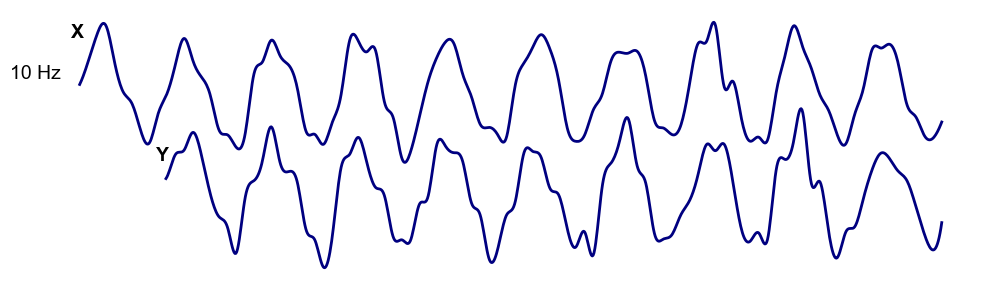

In [25]:
# Select and crop 1 second time-window
start = 0
end = int(sfreq * 1)

t_plot = t[start:end]
x_plot = ch_a[start:end]
y_plot = ch_b[start:end]

# Smoothing the plot
t_fine = np.linspace(t_plot[0], t_plot[-1], 10 * len(t_plot))  # 10x resolution

x_smooth = interp1d(t_plot, x_plot, kind='cubic')(t_fine)
y_smooth = interp1d(t_plot, y_plot, kind='cubic')(t_fine)

# Plot
plt.figure(figsize=(10, 3))

offset = 2
plt.plot(t_fine, x_smooth + offset, color="navy", linewidth=2)

# Mask the the first 10 ms lagged
y_masked = y_smooth.copy()
y_masked[:lag*10] = np.nan

plt.plot(t_fine, y_masked, color="navy", linewidth=2)

# Labels
plt.text(t_fine[0] - 0.01, offset + 1, "X", fontsize=14, fontweight='bold')
plt.text(t_fine[88], 0.6,  "Y", fontsize=14, fontweight='bold') 
plt.text(t_fine[0]- 0.08, offset + 0.2, "10 Hz", fontsize=14)

plt.axis("off")
plt.tight_layout()
plt.show()

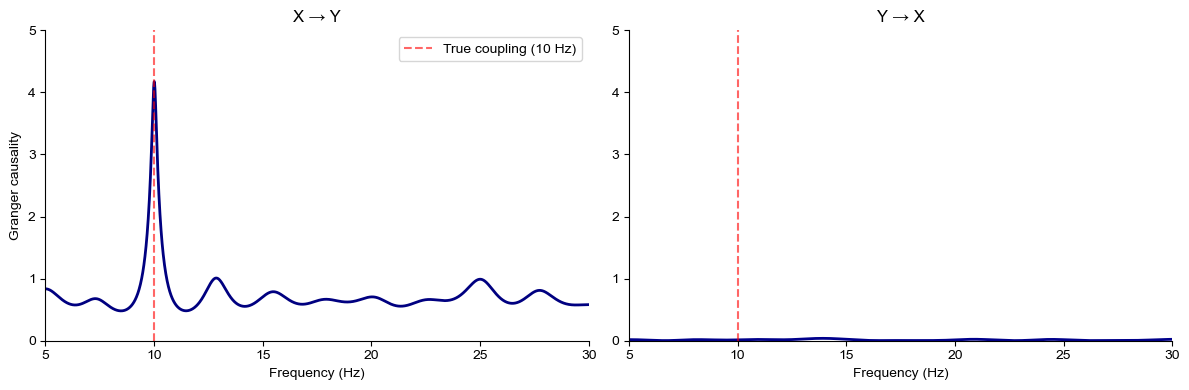

In [26]:
# Styling
plt.rcParams['font.family'] = 'Arial'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plots = [
    (xy, "X → Y", "navy", True),
    (yx, "Y → X", "darkblue", False),
]

for ax, (vals, title, color, show_legend) in zip(axes, plots):
    ax.plot(freqs, vals, linewidth=2, color=color)
    ax.axvline(
        10,
        linestyle="--",
        alpha=0.6,
        color="red",
        label="True coupling (10 Hz)" if show_legend else None,
    )
    
    ax.set_xlim(5, 30)
    ax.set_ylim(0, 5)
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    
    if show_legend:
        ax.set_ylabel("Granger causality")
        ax.legend(loc="upper right")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Statistics

In [27]:
# Convert variables to array
freqs_array = np.asarray(freqs)
xy_array = np.asarray(xy)
yx_array = np.asarray(yx)

# Restrict to required frequencies
mask = (freqs_array >= 5) & (freqs_array <= 20)

# Apply mask
freqs_band = freqs_array[mask]
xy_band = xy_array[mask]
yx_band = yx_array[mask]

In [28]:
# GC summary stats
gc_xy_mean = np.mean(xy_band)
gc_yx_mean = np.mean(yx_band)

gc_xy_sd = np.std(xy_band, ddof=1)
gc_yx_sd = np.std(yx_band, ddof=1)

gc_xy_peak = np.max(xy_band)
gc_yx_peak = np.max(yx_band)

freq_xy_peak = freqs_band[np.argmax(xy_band)]
freq_yx_peak = freqs_band[np.argmax(yx_band)]

print(f"Mean GC X→Y: {gc_xy_mean:.2f}")
print(f"Mean GC Y→X: {gc_yx_mean:.2f}")
print(f"Peak GC X→Y: {gc_xy_peak:.2f} at {freq_xy_peak:.2f} Hz")
print(f"Peak GC Y→X: {gc_yx_peak:.2f} at {freq_yx_peak:.2f} Hz")
print(f"Standard Deviation GC X→Y: {gc_xy_sd:.2f}")
print(f"Standard Deviation GC Y→X: {gc_yx_sd:.2f}")

Mean GC X→Y: 0.78
Mean GC Y→X: 0.01
Peak GC X→Y: 4.17 at 10.01 Hz
Peak GC Y→X: 0.04 at 13.91 Hz
Standard Deviation GC X→Y: 0.50
Standard Deviation GC Y→X: 0.01


In [29]:
# Directionality of channels
directionality_index = (gc_xy_mean - gc_yx_mean) / (gc_xy_mean + gc_yx_mean)

print(f"Directionality index: {directionality_index:.2f}")

Directionality index: 0.96


In [30]:
# Paired t-test
t_stat, p_val = ttest_rel(xy_band, yx_band)

print(f"Paired t-test: t = {t_stat:.2f}, p = {p_val:.2f}")
print(f"Degrees of Freedom (df) = {len(xy_band) - 1}")

Paired t-test: t = 58.85, p = 0.00
Degrees of Freedom (df) = 1500


In [31]:
# Bootstrap confidence interval
n_boot = 1000
boot_diffs = []

for _ in range(n_boot):
    idx = np.random.choice(len(xy_band), len(xy_band), replace=True)
    boot_diffs.append(np.mean(xy_band[idx]) - np.mean(yx_band[idx]))

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print(f"95% CI (X→Y − Y→X): [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI (X→Y − Y→X): [0.7393, 0.7894]


In [32]:
# Predictive validity (VAR)
data_2d = np.vstack([ch_a, ch_b]).T

model = VAR(data_2d)
results = model.fit(maxlags=5)

full_var = np.var(results.resid[:, 1])

model_reduced = AutoReg(data_2d[:, 1], lags=5)
results_reduced = model_reduced.fit()
reduced_var = np.var(results_reduced.resid)

var_reduction = (reduced_var - full_var) / reduced_var * 100

print(f"Prediction error reduction (X → Y): {var_reduction:.2f}%")

Prediction error reduction (X → Y): 18.25%


In [33]:
# ADF
adf_x = adfuller(ch_a)
adf_y = adfuller(ch_b)

print(f"ADF p-value X: {adf_x[1]:.6f}")
print(f"ADF p-value Y: {adf_y[1]:.6f}")

ADF p-value X: 0.000000
ADF p-value Y: 0.000000
